In [417]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [418]:
df=pd.read_csv("laptop_data.csv")

In [419]:
df.head(2)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [420]:
df.shape

(1303, 12)

In [421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


# Data Cleaning

In [422]:
df.duplicated().sum()

np.int64(0)

In [423]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [424]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [425]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [426]:
# Removing kg and GB from Ram and Weight
df['Weight']=df['Weight'].str.replace('kg','')
df['Ram']=df['Ram'].str.replace('GB','')

In [427]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232


In [428]:
# Converting Types of Ram and Weight
df['Ram']=df['Ram'].astype('int32')
df['Weight']=df['Weight'].astype('float32')

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 101.9+ KB


In [430]:
#Converting Price from INR to PKR
df['Price']=df['Price']*3

# EDA and Feature Engineering

In [431]:
import seaborn as sns

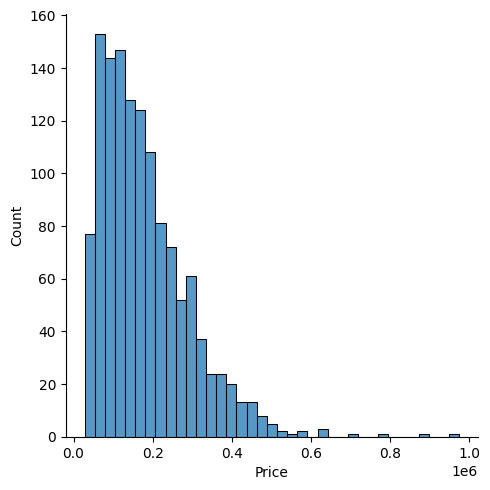

In [432]:
sns.displot(df['Price'])

**Insights**: The Price distribution of thr laptops is left-skewed meaning that datasets contains less expensive laptops than over-budget laptops 

# Column no.1: Company

<Axes: xlabel='Company'>

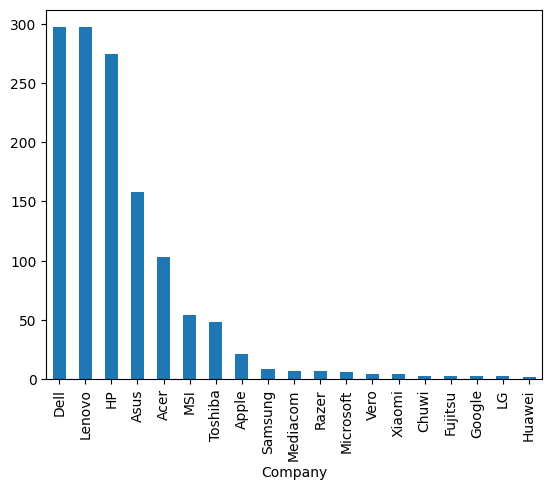

In [433]:
df['Company'].value_counts().plot(kind='bar')

**Insights**: Dataset contains laptops from 12 different companies and contains more data of some companys like Dell,HP, Lenovo ,Asus

# Prices W.r.t Compaines

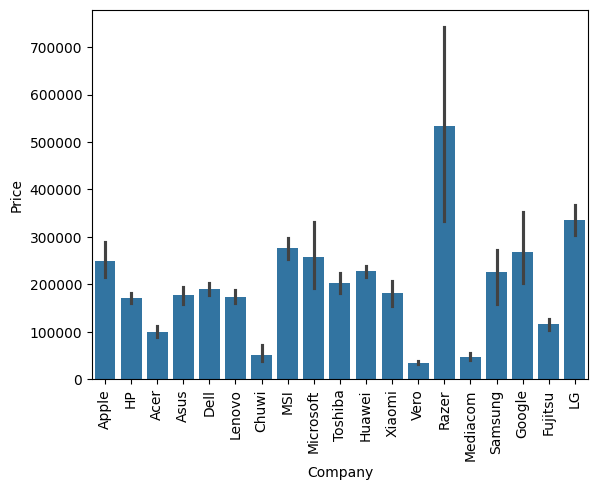

In [434]:
sns.barplot(x=df['Company'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()

**Insights**: The Prices of the Laptops varies from company to company. so Price of the laptop is also dependent upon the brand/company of the laptop

# Column no.2: TypeName

<Axes: xlabel='TypeName'>

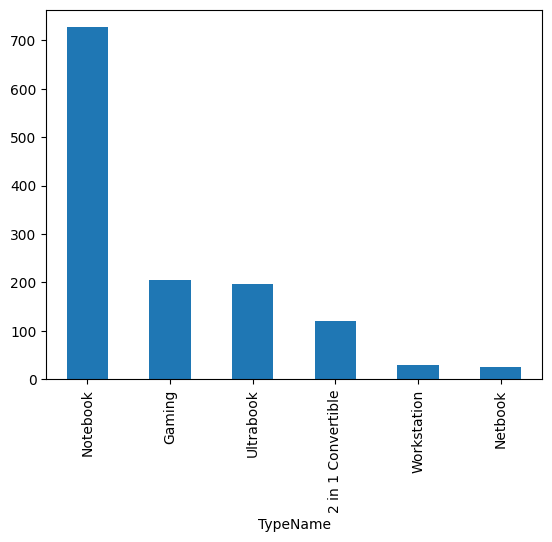

In [435]:
df['TypeName'].value_counts().plot(kind=('bar'))

**Insights**: Dataset contains laptops of 6 different types  and contains more data of notebook laptops which indicates more notebooks are sold more.

# Prices W.r.t TypeName

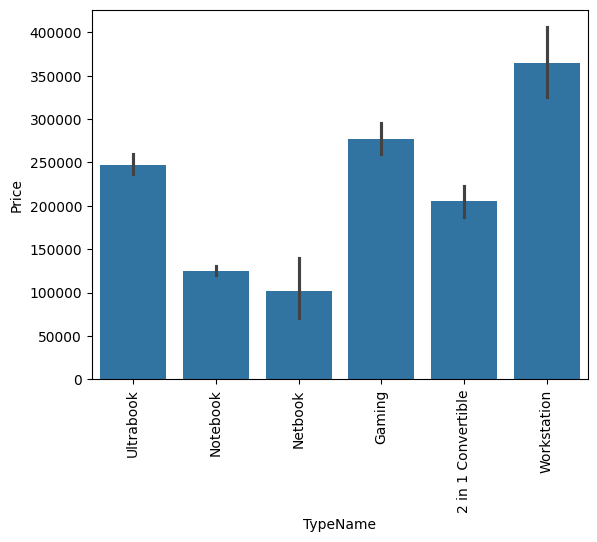

In [436]:
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()


**Insights**: The Prices of the Laptops varies also from types to types. so Price of the laptop is also dependent upon the Type of the laptop

# Column no.3: Inches

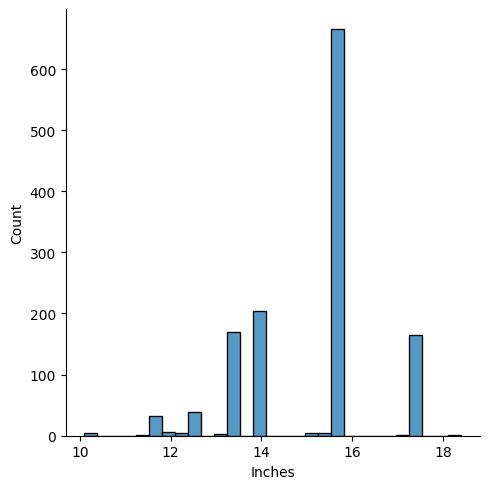

In [437]:
sns.displot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price'>

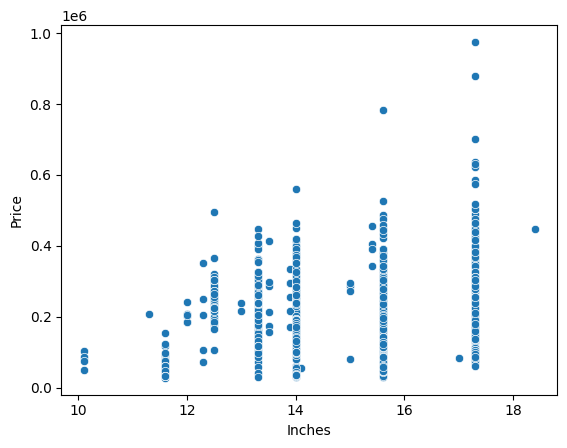

In [438]:
sns.scatterplot(x=df['Inches'],y=df['Price'])

**Insights**: The Prices of the Laptops varies a bit less dependent upon the size of laptops. As the size increases the laptop price range also increases but in the middle it between 12 and 16 it price rabge remains almost the same 

# Column no.4: Screen Resolution

In [439]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

# Feature Engineering ScreenResolution
In this column, We can extract 3 different types of features

1. Screen Resolution 
2. Touch Screen or Not
3. IPS Panel or Not

So we Approach Them One-by-one

**1. Touch Screen** 

In [440]:
df['TouchScreen']=df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

<Axes: xlabel='TouchScreen'>

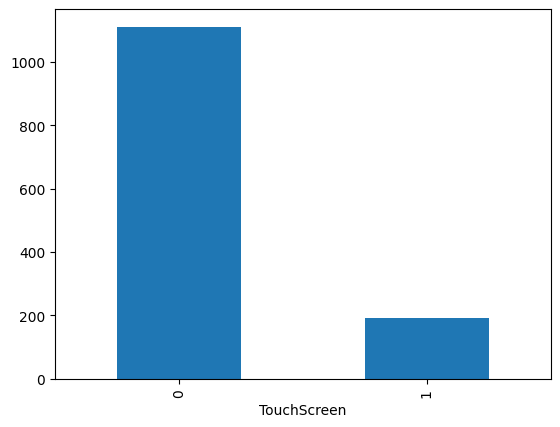

In [441]:
df['TouchScreen'].value_counts().plot(kind='bar')

<Axes: xlabel='TouchScreen', ylabel='Price'>

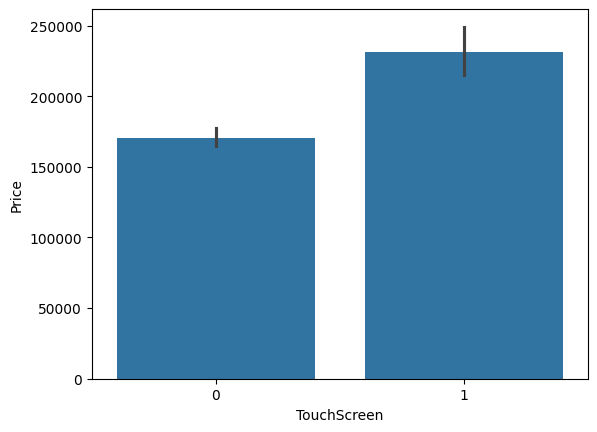

In [442]:
sns.barplot(x=df['TouchScreen'],y=df['Price'])

**Insights**: The Prices of the Laptops is dependent upon the touchscreen feature of screen of laptops. The laptops values more if it has a touch screen 

**2. IPS Panel** 

In [443]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS Panel' in x else 0)

In [444]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
265,Dell,2 in 1 Convertible,15.6,Full HD / Touchscreen 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,2.67,127712.1600,1,0
680,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,256GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.20,159504.3360,0,0
106,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Intel HD Graphics 520,Windows 10,1.85,66317.6160,0,0
350,Dell,Notebook,15.6,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,16,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.06,324062.8128,1,0
361,Asus,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,2.00,151048.8000,0,0


<Axes: xlabel='IPS'>

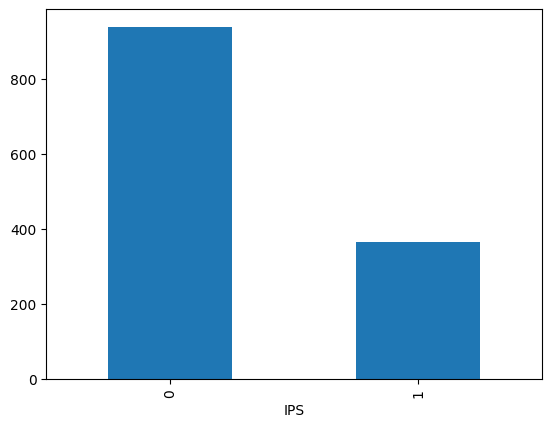

In [445]:
df['IPS'].value_counts().plot(kind='bar')

<Axes: xlabel='IPS', ylabel='Price'>

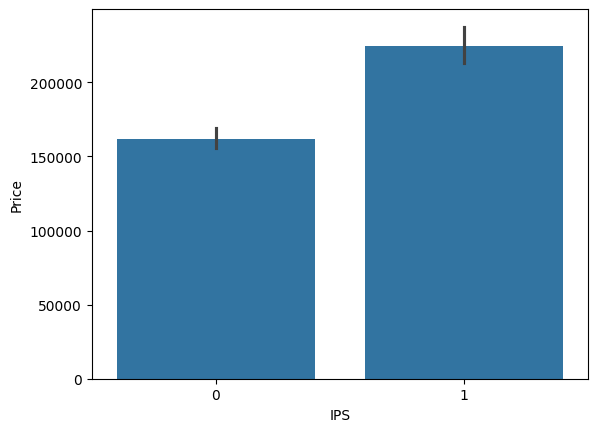

In [446]:
sns.barplot(x=df['IPS'],y=df['Price'],)

**Insights**: Laptops with IPS Panel Value more than the non Ips Panel One. So Laptop price is dependent upon the IPS feature of the laptop

**3. Screen Resolution**

In [447]:
new=df['ScreenResolution'].str.split("x",n=1,expand=True)
df['X_res']=new[0]
df['Y_res']=new[1]

In [448]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,214136.0496,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,143686.5696,0,0,1440,900


In [449]:
df['X_res']=df['X_res'].str.replace(",","").str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [450]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
953,Asus,2 in 1 Convertible,12.5,Full HD 1920x1080,Intel Core M M7-6Y75 1.2GHz,8,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.20,185254.5600,0,0,1920,1080
550,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,2.20,79760.1600,0,0,1920,1080
264,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,1TB HDD,AMD Radeon R5 M430,Windows 10,2.24,90309.6000,0,0,1920,1080
127,Asus,Notebook,14.0,1366x768,AMD E-Series 6110 1.5GHz,4,64GB SSD,AMD Radeon R2,Windows 10 S,1.65,44433.9216,0,0,1366,768
1086,HP,Workstation,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,AMD FirePro W4190M,Windows 7,1.90,238960.8000,0,0,1920,1080


In [451]:
df['X_res']=df['X_res'].astype('int32')
df['Y_res']=df['Y_res'].astype('int32')

In [452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   int32  
 14  Y_res             1303 non-null   int32  
dtypes: float32(1), float64(2), int32(3), int64(2), object(7)
memory usage: 132.5+ KB


In [453]:
df.corr(numeric_only=True)['Price']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price          1.000000
TouchScreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
Name: Price, dtype: float64

This correlaion tells till now we have strong relations between price and Inches and X_res,Y_res.

But we can't use X_res , Y_res in our Dataset Instead we would use Pixel Per Inches(PPI) using Inches,X_res and Y_res.

In [454]:
df['PPi']=((df['X_res']**2)+(df['Y_res']**2))**0.5/df['Inches']

In [455]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res,PPi
346,HP,Notebook,14.0,1366x768,Intel Celeron Dual Core N3060 1.6GHz,2,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.44,44595.3600,0,0,1366,768,111.935204
434,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16,512GB SSD,Nvidia Quadro M2200M,Windows 10,2.50,391448.1600,0,0,1920,1080,141.211998
1063,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,2TB HDD,AMD Radeon R7 M445,Windows 10,2.32,158240.0016,0,0,1920,1080,141.211998
1045,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6300U 2.4GHz,8,256GB SSD + 500GB HDD,Intel HD Graphics 520,Windows 10,1.84,336197.8656,0,0,1920,1080,141.211998
953,Asus,2 in 1 Convertible,12.5,Full HD 1920x1080,Intel Core M M7-6Y75 1.2GHz,8,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.20,185254.5600,0,0,1920,1080,176.232574


In [456]:
df.corr(numeric_only=True)['Price']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price          1.000000
TouchScreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
PPi            0.473487
Name: Price, dtype: float64

Now Dropping Screenresolution because we have PPI,touchscreen and IPS columns

And Dropping X_res,Y_res and Inches becaues Now we Have PPI on the Bases of those columns

In [457]:
df.drop(columns=['X_res','Y_res','Inches','ScreenResolution'],inplace=True)

In [458]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,214136.0496,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,143686.5696,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,91908.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,405586.0080,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,288287.4240,0,1,226.983005


# Column no.5: Cpu

In [459]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

# Feature Engineering Cpu

**We would categorize the Cpu into Inter core i5,i7,i3 ,AMD and other processers category.**

In [460]:
df['CPU Brand']=df['Cpu'].apply(lambda x:" ".join(x.split(" ")[0:3]))

In [461]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPi,CPU Brand
21,Lenovo,Gaming,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.50,159680.1600,0,1,141.211998,Intel Core i5
595,Lenovo,Notebook,Intel Core i3 6100U 2.3GHz,8,1TB HDD,Intel HD Graphics 520,Windows 10,2.29,73366.5600,0,0,100.454670,Intel Core i3
90,Asus,Gaming,AMD FX 9830P 3GHz,8,1TB HDD,AMD Radeon RX 560,Windows 10,2.45,111728.1600,0,0,141.211998,AMD FX 9830P
925,Dell,Notebook,Intel Core i5 6200U 2.3GHz,4,500GB HDD,Intel HD Graphics 520,Windows 10,1.95,116667.2160,0,0,100.454670,Intel Core i5
396,Lenovo,Notebook,Intel Core i7 8550U 1.8GHz,8,256GB SSD,AMD Radeon RX 550,Windows 10,2.10,196532.8704,0,1,141.211998,Intel Core i7


In [462]:
def fetch_processor(text):
    if text in ['Intel Core i7','Intel Core i3','Intel Core i5']:
        return text
    elif text.split(' ')[0]=='Intel':
        return "Other Intel Processor"
    else:
        return "AMD Processor"

In [463]:
df['CPU Brand']=df['CPU Brand'].apply(fetch_processor)

<Axes: xlabel='CPU Brand'>

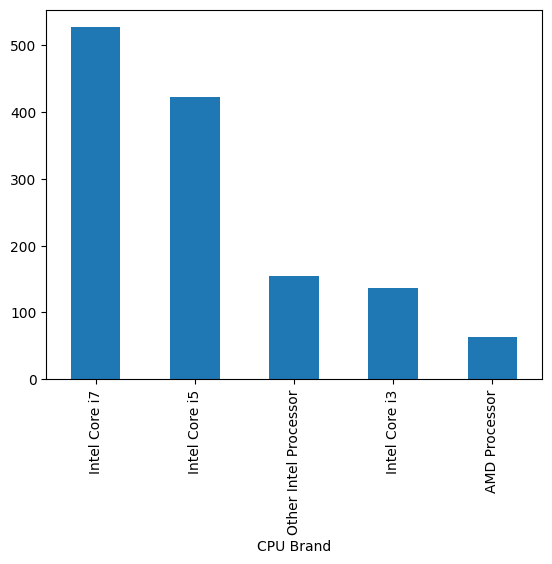

In [464]:
df['CPU Brand'].value_counts().plot(kind='bar')

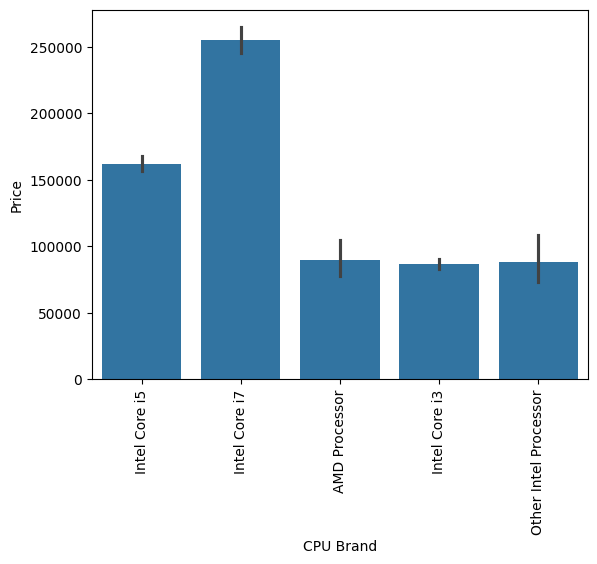

In [465]:
sns.barplot(x=df['CPU Brand'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()

**Insights**: So this analysis shows dataset contains more data of inter core i5 and i7 laptops and price of laptop varies with variation in the CPU Brand which is an important feature for our model to be created. The Price of laptops old processers like AMD, core i3 and other Intel Processers have similar and less price While CPU like Intel Core i5 and i7 are too more expensive.

In [466]:
df.drop(columns=['Cpu'],inplace=True)

In [467]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPi,CPU Brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,214136.0496,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,143686.5696,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,91908.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,405586.0080,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,288287.4240,0,1,226.983005,Intel Core i5


# Column No.6: RAM

<Axes: xlabel='Ram'>

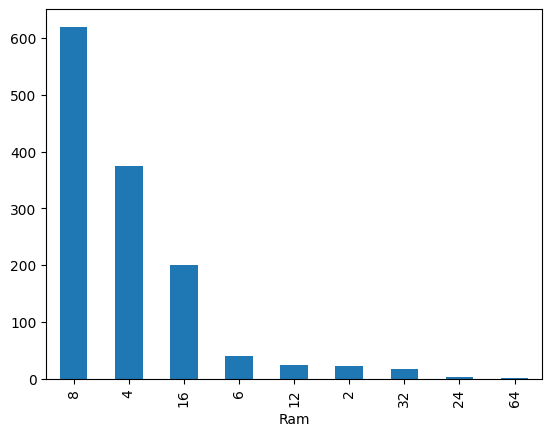

In [468]:
df['Ram'].value_counts().plot(kind='bar')

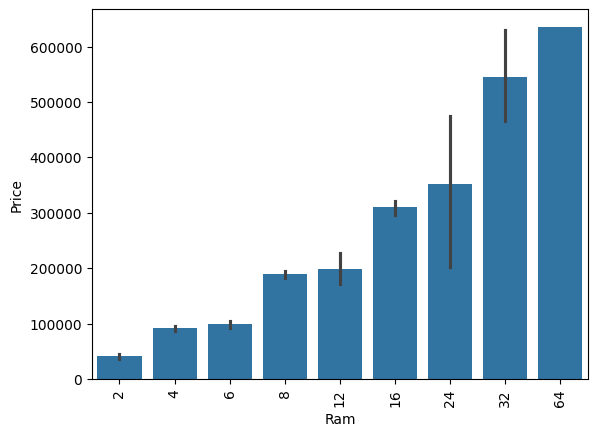

In [ ]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()

In [490]:
df.rename(columns={"Ram":"RAM"},inplace=True)

**Insights**: We see price increase highly as the size of the Ram Increases so it has a very high relation with Prize And Ram has most values 8 and 4 which shows thta many people still prefer budget friendly laptop.

# Column no.7: Memory

In [470]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

# Feature Engineering Memory
In this column as there are 4 differnet categories we would create four new columns:
1. Flash
2. SSD
3. HDD
4. Hybrid

As a laptop can also have only SSD,both or all Memories

In [ ]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)#.0 from values
df["Memory"] = df["Memory"].str.replace('GB', '')#removing GB with values
df["Memory"] = df["Memory"].str.replace('TB', '000')# Converting TB to GB
new = df["Memory"].str.split("+", n = 1, expand = True) # Splitting the memories

df["first"]= new[0]#First memory column
df["first"]=df["first"].str.strip()

df["second"]= new[1]#2nd Memory Column

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)#First Memory SSD
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)#First Memory HDD
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)#First Memory Hybrid
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)#First Memory Flash

df["second"].fillna("0", inplace = True)#filling None with Zeros

#Creating columns for second Memory types same as for column first
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '')

#Removing Memory Type from Columns first and second
df['first']=df['first'].apply(lambda x:x.split()[0])
df['second']=df['second'].apply(lambda x:x.split()[0])

#Converting Types of col to int
df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

#Creating New Columns HDD,Flash, Hybrid and SSD and storing the deisred memory value
#  in the desired column
df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

#Dropping Extra Columns
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\User\AppData\Local\Temp\ipykernel_20228\3153169852.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)#.0 from values
C:\Users\User\AppData\Local\Temp\ipykernel_20228\3153169852.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)#filling None with Zeros


In [476]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPi,CPU Brand,HDD,SSD,Hybrid,Flash_Storage
968,Dell,Gaming,32,256 SSD + 1000 HDD,Nvidia GeForce GTX 1070,Windows 10,4.42,503336.1600,0,1,127.335675,Intel Core i7,1000,256,0,0
802,Dell,Ultrabook,8,256 SSD,Intel HD Graphics 620,Windows 10,1.29,239600.1600,0,0,165.632118,Intel Core i5,0,256,0,0
347,Dell,Ultrabook,16,512 SSD + 256 SSD,Intel UHD Graphics 620,Windows 10,1.88,257016.3264,0,0,141.211998,Intel Core i7,0,768,0,0
323,HP,Notebook,8,1000 HDD,Intel UHD Graphics 620,Windows 10,2.10,144175.6800,0,1,100.454670,Intel Core i7,1000,0,0,0
75,Asus,Gaming,8,1000 HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,151688.1600,0,0,141.211998,Intel Core i7,1000,0,0,0


In [477]:
df.drop(columns=['Memory'],inplace=True)

In [480]:
df.corr(numeric_only=True)['Price']

Ram              0.743007
Weight           0.210370
Price            1.000000
TouchScreen      0.191226
IPS              0.252208
PPi              0.473487
HDD             -0.096441
SSD              0.670799
Hybrid           0.007989
Flash_Storage   -0.040511
Name: Price, dtype: float64

**Insights**: Here We see SSD have strong relation with price, HDD have a negative and bit less but considerable relation with Price. On the other hand, Hybrid and Flash_Storage have very weak relation with the so we drop these columns 

In [481]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [482]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPi,CPU Brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,214136.0496,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,143686.5696,0,0,127.677940,Intel Core i5,0,0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,91908.0000,0,0,141.211998,Intel Core i5,0,256
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,405586.0080,0,1,220.534624,Intel Core i7,0,512
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,288287.4240,0,1,226.983005,Intel Core i5,0,256


# Column No.8: Gpu

In [483]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

Here we would Just Extract the GPU Brand Names Because we have huge number of categories with a very less quantity

In [ ]:
df['GPU Brand']=df['Gpu'].apply(lambda x:x.split()[0])

In [491]:
df.drop(columns=['Gpu'],inplace=True)

In [494]:
df['GPU Brand'].value_counts()

GPU Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [498]:
df=df[df['GPU Brand']!='ARM']

In [499]:
df['GPU Brand'].value_counts()

GPU Brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

<Axes: xlabel='GPU Brand'>

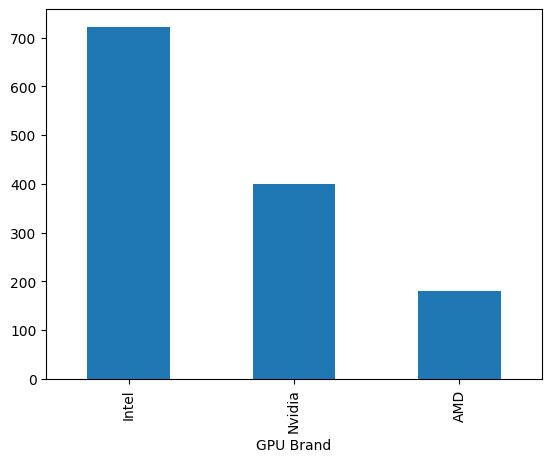

In [500]:
df['GPU Brand'].value_counts().plot(kind='bar')

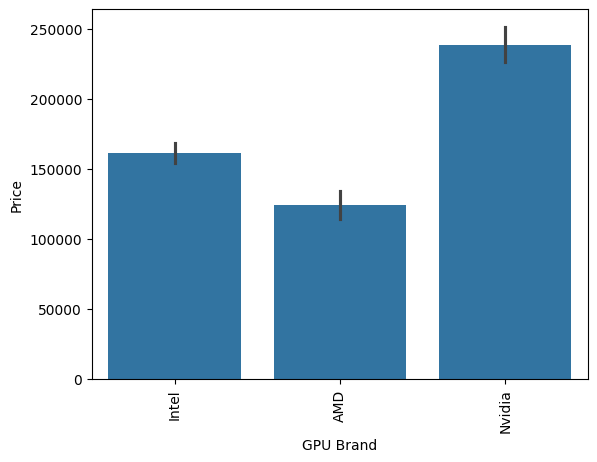

In [502]:
sns.barplot(x=df['GPU Brand'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()

**Insights**: These plots show that Price is different when we use different GPU. SO GPU Brand is an important feature in price predicting

# Column no.9: Opsys

In [ ]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

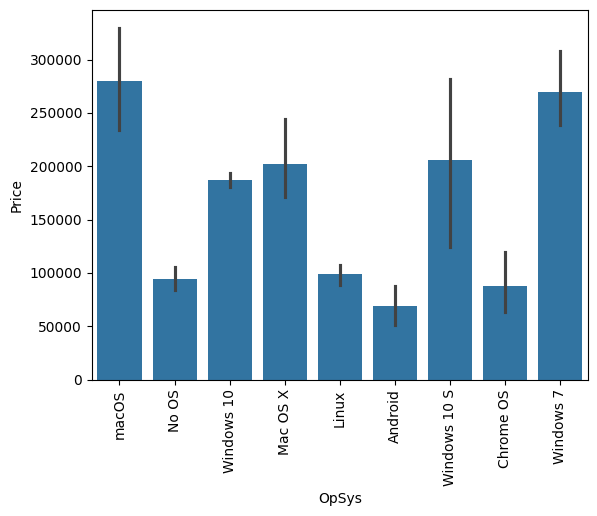

In [505]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation="vertical")
plt.show()

Here we can see Windows have high Price, Mac have high but a bit less that Windows While Others have the same price. so In total we have 3 categories Windows, Mac and Others.

# Feature Engineering OpSys 

In [506]:
def fetch_OS(text):
    if text in ['Windows 10','Windows 7','Windows 10 S']:
        return 'Windows'
    elif text in ['macOS','Mac OS X']:
        return "Mac"
    else:
        return "Other/No OS/LInux"

In [508]:
df['OpSys']=df['OpSys'].apply(fetch_OS)

In [510]:
df.rename(columns={'OpSys':'OS'},inplace=True)
df.head()

,Company,TypeName,RAM,OS,Weight,Price,TouchScreen,IPS,PPi,CPU Brand,HDD,SSD,GPU Brand
0,Apple,Ultrabook,8,Mac,1.37,214136.0496,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Mac,1.34,143686.5696,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Other/No OS/LInux,1.86,91908.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,Mac,1.83,405586.0080,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Mac,1.37,288287.4240,0,1,226.983005,Intel Core i5,0,256,Intel


<Axes: xlabel='OS', ylabel='Price'>

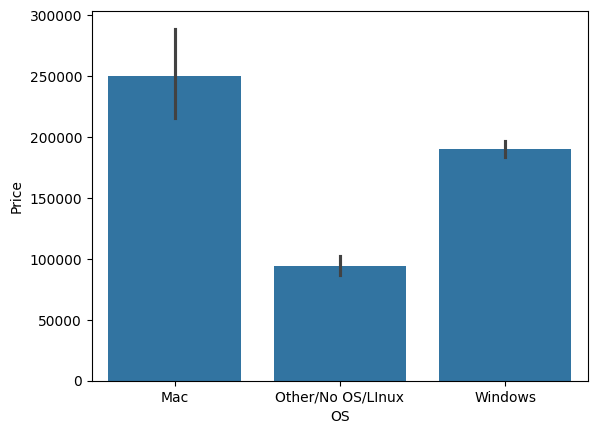

In [511]:
sns.barplot(x=df['OS'],y=df['Price'])

**Insights**: Now we can see that Price is diff for diff OS. so Highest among them is Mac then Windodws and Then Other OS categories.

# Column no.10:Weight

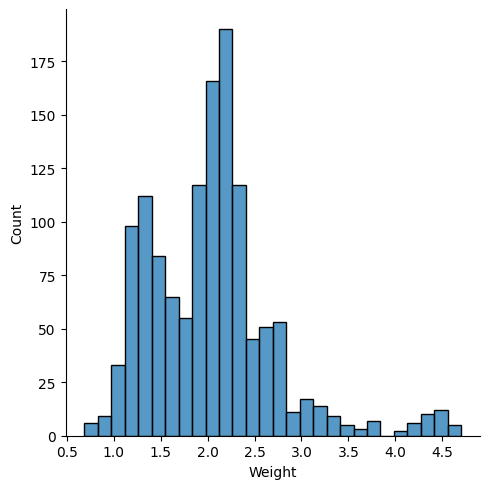

In [512]:
sns.displot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

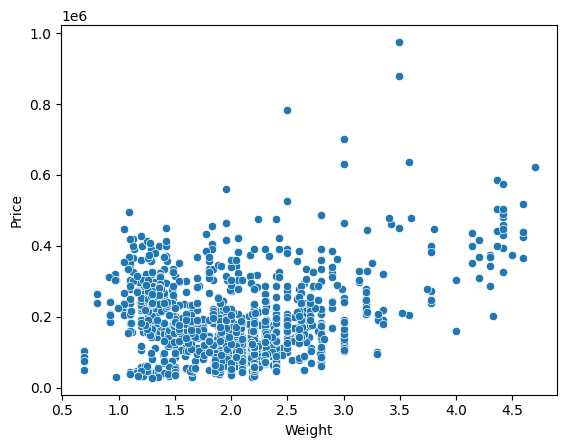

In [514]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

In [515]:
df.corr(numeric_only=True)['Price']

RAM            0.742905
Weight         0.209867
Price          1.000000
TouchScreen    0.192917
IPS            0.253320
PPi            0.475368
HDD           -0.096891
SSD            0.670660
Name: Price, dtype: float64

**Insights**:We see there is small linear relationship between weight and price which is not very strong but considerable relationship for our model.

# Correlation Matrix

<Axes: >

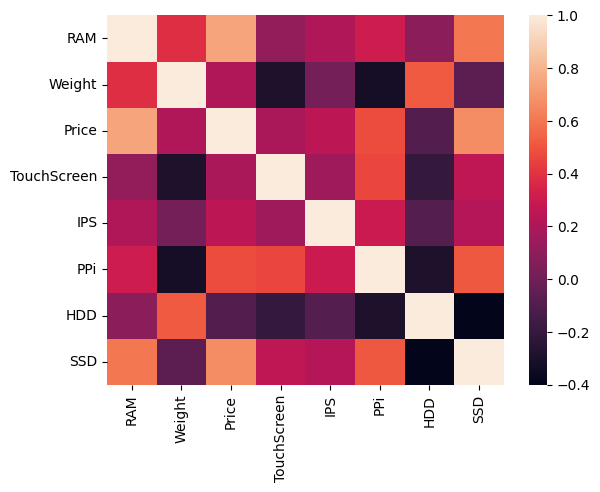

In [518]:
sns.heatmap(df.corr(numeric_only=True))

As we can see no other column is stronly related to any other column in the dataset so we are ready to go as all our columns are useful.

# Column no.11: Price (Target)

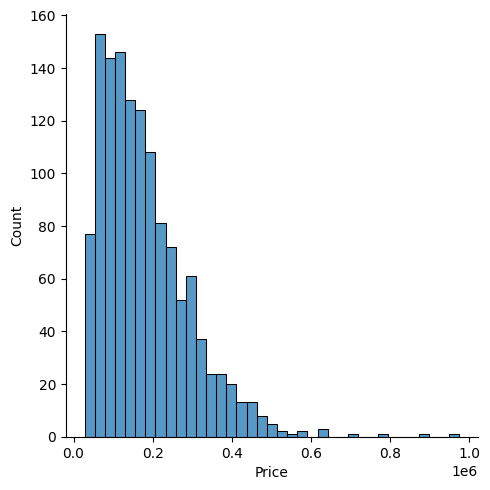

In [519]:
sns.displot(df['Price'])

Here we see that our target value is distributed left skewed so apply log transformation to make the distribution Normal. 

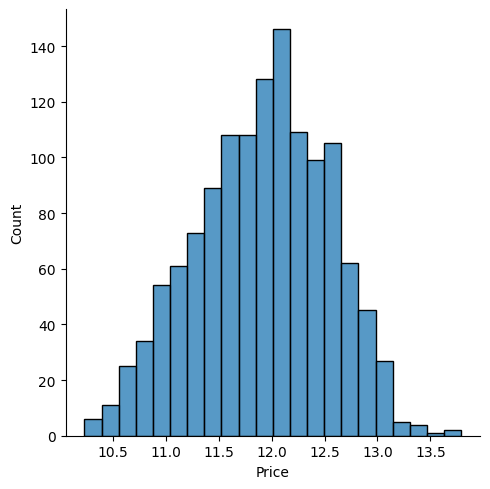

In [520]:
sns.displot(np.log(df['Price']))

Now at Log Transformation Our Target Distribution is Normal and Well Behaved